In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
df=pd.read_csv("D:/EDA/data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()
df.info()
df.isnull().sum()
#print("Total missing value:",df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop(columns=[
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
])
df.shape
X = df.drop("Attrition", axis=1)
y = df["Attrition"]
print(y.value_counts())
y = y.map({
    "No": 0,
    "Yes": 1
})

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()
print("Categorical features:")
print(categorical_features)
print("\nNumerical features:")
print(numerical_features)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

C:\Users\atchu\AppData\Local\Temp\ipykernel_22824\1499484987.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)




In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Age','BusinessTravel','DailyRate',...,'YearsInCurrentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

In [23]:
y_pred = logistic_model.predict(X_test)
y_pred[:10]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8639455782312925
Precision: 0.64
Recall   : 0.3404255319148936
F1 Score : 0.4444444444444444


In [25]:
y_probability = logistic_model.predict_proba(X_test)[:, 1]

print("ROC-AUC  :", roc_auc_score(y_test, y_probability))

ROC-AUC  : 0.8102334395727453


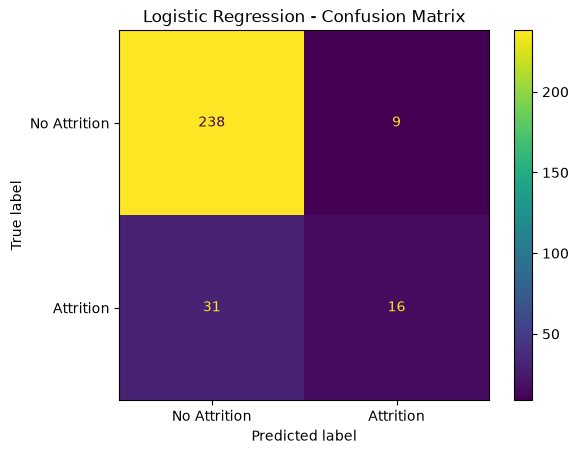

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Random Forest Performance
-------------------------
Accuracy : 0.8333333333333334
Precision: 0.46875
Recall   : 0.3191489361702128
F1 Score : 0.379746835443038
ROC-AUC  : 0.7796106469118788


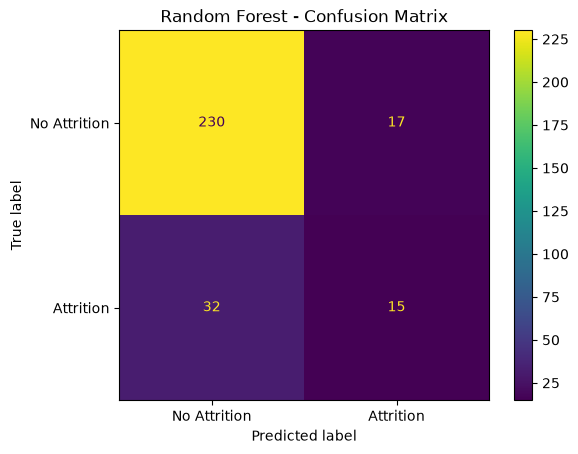

In [27]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)
random_forest_model.fit(X_train, y_train)
rf_pred = random_forest_model.predict(X_test)
rf_probability = random_forest_model.predict_proba(X_test)[:, 1]
print("Random Forest Performance")
print("-------------------------")

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_probability))
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

XGBoost Performance
-------------------
Accuracy : 0.8605442176870748
Precision: 0.6875
Recall   : 0.23404255319148937
F1 Score : 0.3492063492063492
ROC-AUC  : 0.7874924627444224


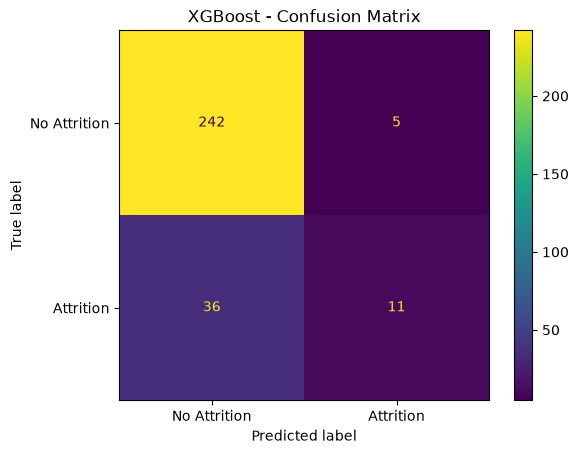

In [29]:
from xgboost import XGBClassifier
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_probability = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost Performance")
print("-------------------")

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_probability))
cm_xgb = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Attrition", "Attrition"]
)

disp.plot()
plt.title("XGBoost - Confusion Matrix")
plt.show()

In [30]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_probability),
        roc_auc_score(y_test, rf_probability),
        roc_auc_score(y_test, xgb_probability)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8639,0.6400,0.3404,0.4444,0.8102
1,Random Forest,0.8333,0.4688,0.3191,0.3797,0.7796
2,XGBoost,0.8605,0.6875,0.2340,0.3492,0.7875


In [32]:
from sklearn.model_selection import GridSearchCV
rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}
("classifier", RandomForestClassifier(...))
rf_grid = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)
print("Best Parameters:")
print(rf_grid.best_params_)
print("Best Cross-Validation F1 Score:")
print(rf_grid.best_score_)
best_rf_model = rf_grid.best_estimator_
rf_tuned_pred = best_rf_model.predict(X_test)

rf_tuned_probability = best_rf_model.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Performance")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_test, rf_tuned_pred))
print("Precision:", precision_score(y_test, rf_tuned_pred))
print("Recall   :", recall_score(y_test, rf_tuned_pred))
print("F1 Score :", f1_score(y_test, rf_tuned_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_tuned_probability))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best Cross-Validation F1 Score:
0.4919358288770053
Tuned Random Forest Performance
--------------------------------
Accuracy : 0.8333333333333334
Precision: 0.47619047619047616
Recall   : 0.425531914893617
F1 Score : 0.449438202247191
ROC-AUC  : 0.7724179515892841


In [33]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Before Tuning",
        "Random Forest - After Tuning"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, rf_tuned_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, rf_tuned_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, rf_tuned_pred)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, rf_tuned_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_probability),
        roc_auc_score(y_test, rf_tuned_probability)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest - Before Tuning,0.8333,0.4688,0.3191,0.3797,0.7796
1,Random Forest - After Tuning,0.8333,0.4762,0.4255,0.4494,0.7724


In [34]:

feature_names = best_rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()
print("Number of features:", len(feature_names))
importances = best_rf_model.named_steps[
    "classifier"
].feature_importances_
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(20)

Number of features: 44


,Feature,Importance
9,num__MonthlyIncome,0.081595
0,num__Age,0.064372
43,cat__OverTime_Yes,0.054920
1,num__DailyRate,0.054681
16,num__TotalWorkingYears,0.052124
19,num__YearsAtCompany,0.049008
22,num__YearsWithCurrManager,0.046483
5,num__HourlyRate,0.040354
10,num__MonthlyRate,0.039840
15,num__StockOptionLevel,0.039643


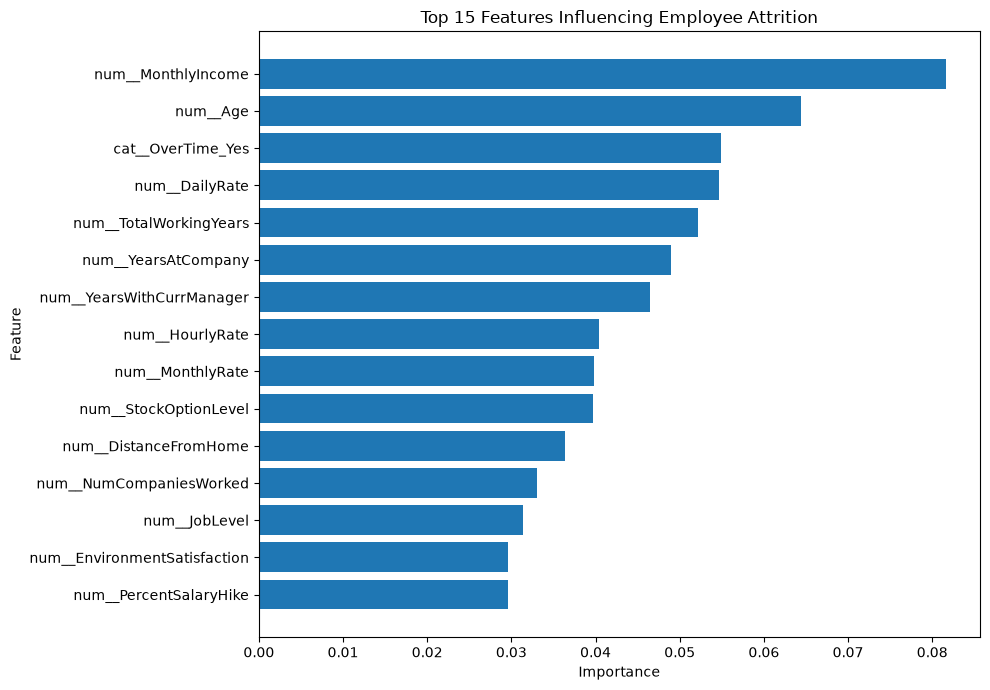

In [35]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Employee Attrition")

plt.tight_layout()
plt.show()

In [36]:
import shap
X_test_transformed = best_rf_model.named_steps[
    "preprocessor"
].transform(X_test)
explainer = shap.TreeExplainer(
    best_rf_model.named_steps["classifier"]
)
shap_values = explainer.shap_values(
    X_test_transformed
)
print(X_test_transformed.shape)
print(len(feature_names))

(294, 44)
44


In [38]:
X_test_transformed = best_rf_model.named_steps[
    "preprocessor"
].transform(X_test)

explainer = shap.TreeExplainer(
    best_rf_model.named_steps["classifier"]
)

shap_values = explainer.shap_values(
    X_test_transformed
)
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP arrays:", len(shap_values))
    print("Shape:", shap_values[0].shape)
else:
    print("Shape:", shap_values.shape)
if isinstance(shap_values, list):
    shap_values_attrition = shap_values[1]
else:
    if len(shap_values.shape) == 3:
        shap_values_attrition = shap_values[:, :, 1]
    else:
        shap_values_attrition = shap_values

print("SHAP shape:", shap_values_attrition.shape)
print("Feature shape:", X_test_transformed.shape)

<class 'numpy.ndarray'>
Shape: (294, 44, 2)
SHAP shape: (294, 44)
Feature shape: (294, 44)


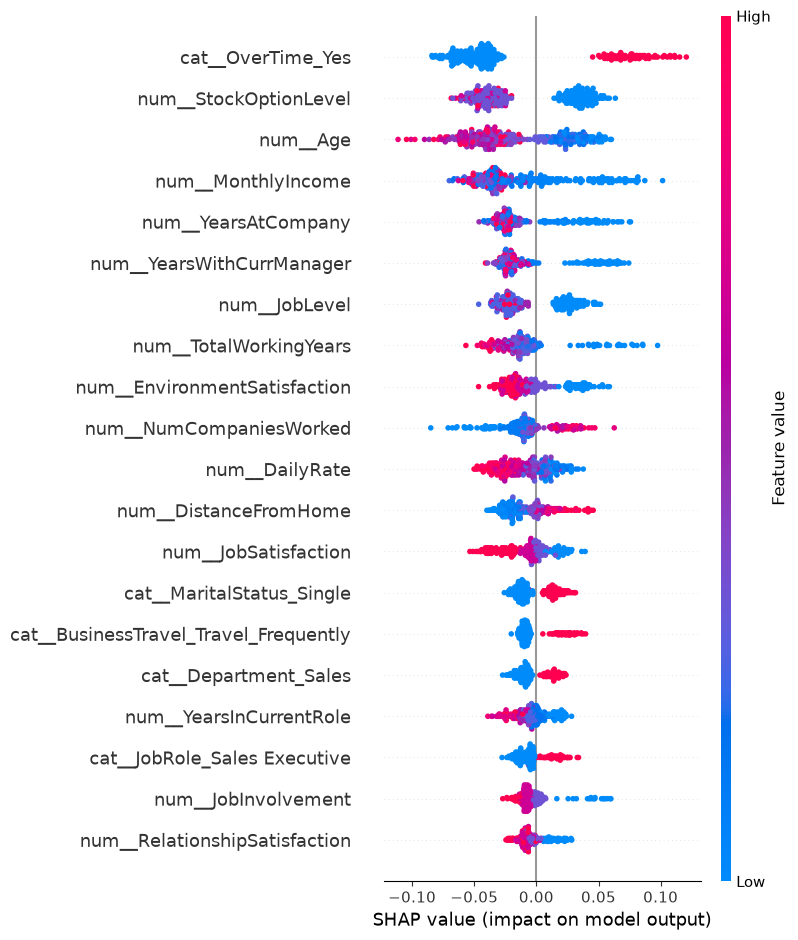

In [39]:
shap.summary_plot(
    shap_values_attrition,
    X_test_transformed,
    feature_names=feature_names
)


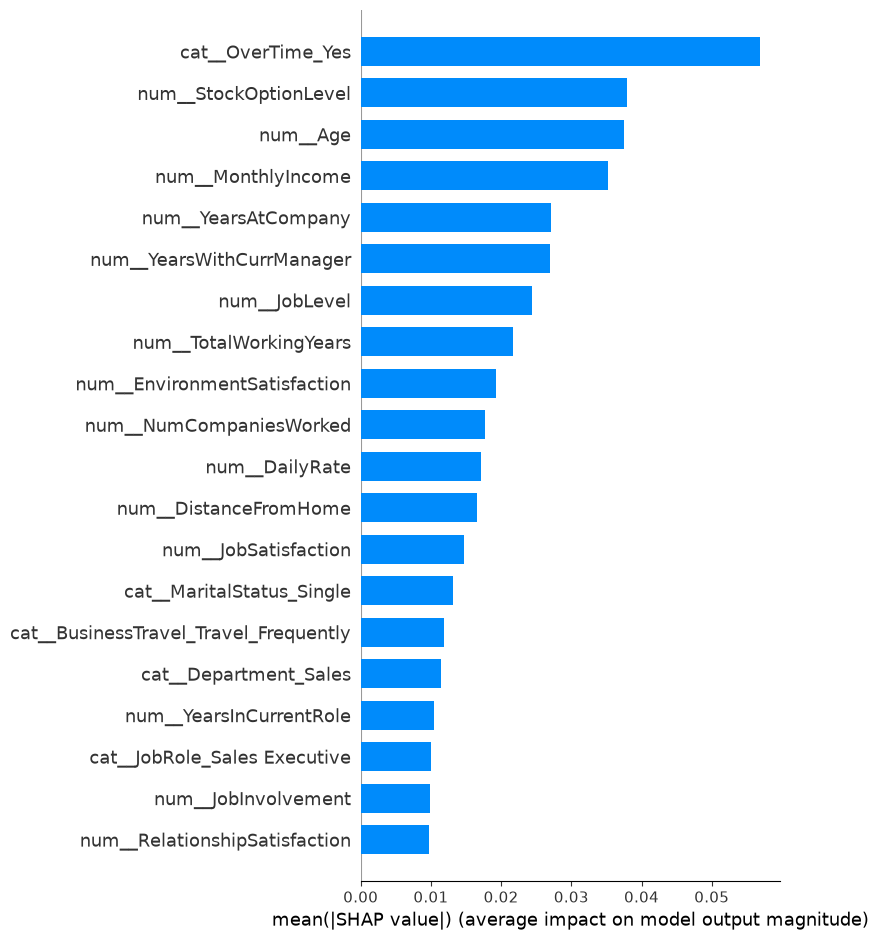

In [40]:
shap.summary_plot(
    shap_values_attrition,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

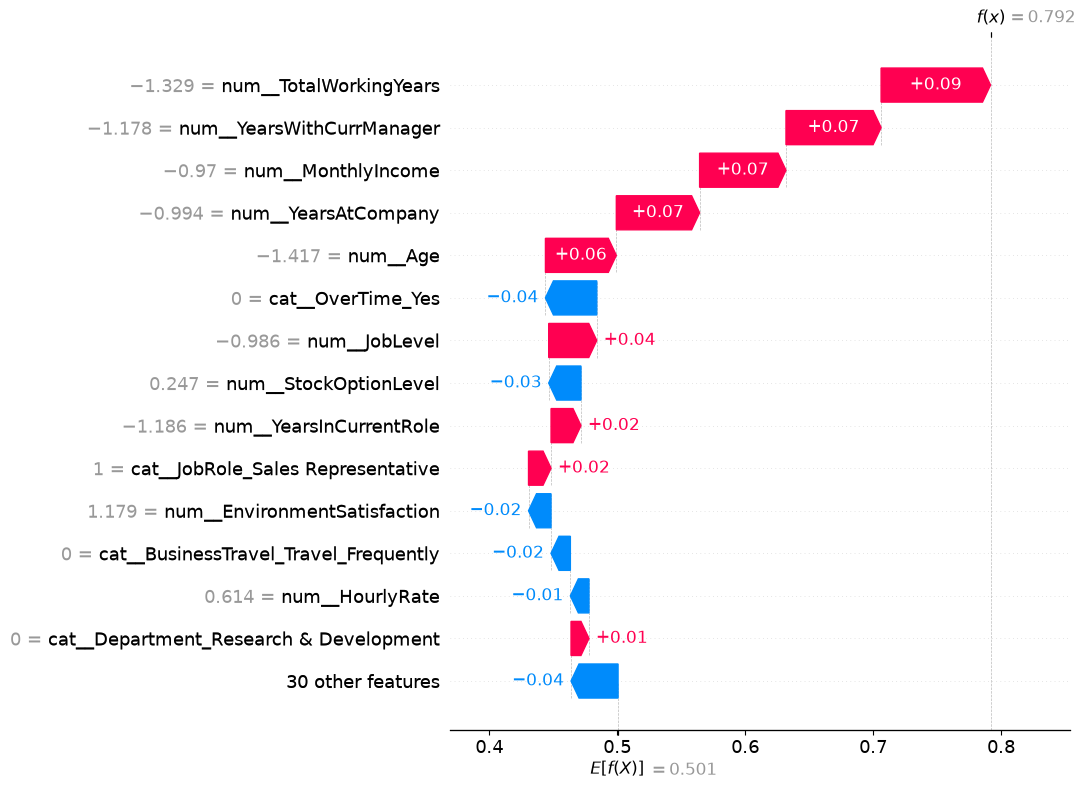

In [41]:
sample_index = 0
sample = X_test_transformed[sample_index]
sample_explanation = shap.Explanation(
    values=shap_values_attrition[sample_index],
    base_values=explainer.expected_value[1]
        if isinstance(explainer.expected_value, (list, np.ndarray))
        else explainer.expected_value,
    data=sample,
    feature_names=feature_names
)
shap.waterfall_plot(sample_explanation, max_display=15)

In [42]:
sample_employee = X_test.iloc[[sample_index]]
prediction = best_rf_model.predict(sample_employee)[0]
probability = best_rf_model.predict_proba(sample_employee)[0][1]
print("Prediction:", prediction)
print(f"Attrition Probability: {probability:.2%}")

Prediction: 1
Attrition Probability: 79.17%


In [43]:
import joblib

joblib.dump(
    best_rf_model,
    "../best_attrition_model.pkl"
)

['../best_attrition_model.pkl']